# Gamma-Ray Source Population & Peak Detection

**Overview:**  
This notebook simulates a realistic Galactic gamma-ray source population using gammapop, creates sky maps, applies angular resolution (PSF), and detects flux peaks.

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord, Angle
from astropy.convolution import Gaussian2DKernel, convolve
from astropy.table import Table

# Gammapop imports
from gammapop.model import PopulationModel
from gammapop.model.spatial import (
    CompoundSpatialModel,
    ReidSpatialModel, 
    SormaniSpatialModel
)
from gammapop.model.source import (
    IndependentSourcePropertyModel,
    PowerLawModel
)
from gammapop.survey import HGPS
from gammapop.utils.skymap import get_observation_window, get_sky_map
from gammapop.utils.visualise import plot_sky_map

# Gammapy imports
from gammapy.maps import Map, WcsGeom
from gammapy.estimators import FluxMaps
from gammapy.estimators.utils import find_peaks_in_flux_map

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Create Population Model

Following the tutorial workflow, we create a spatial model (spiral arms + bar/bulge) and source property models (luminosity and radius distributions).

In [41]:
# Spatial distribution: compound model with spiral arms (Reid) + bar/bulge (Sormani)
# 35% of sources in the bar/bulge region
spatial_model = CompoundSpatialModel(
    disc=ReidSpatialModel(), 
    bar=SormaniSpatialModel(), 
    fraction_bar=0.35
)

# Source property models: power law distributions for luminosity and radius
luminosity_model = PowerLawModel(
    "luminosity", 
    alpha=-1.5, 
    xmin=1e32 / u.s, 
    xmax=1e35 / u.s
)

radius_model = PowerLawModel(
    "radius", 
    alpha=-0.5, 
    xmin=1.0 * u.pc, 
    xmax=100.0 * u.pc
)

# Combine into complete population model
population_model = PopulationModel(
    spatial_model=spatial_model,
    source_model=IndependentSourcePropertyModel(
        luminosity_model=luminosity_model,
        radius_model=radius_model,
    ),
)

print(" Population model created successfully!")
print(f"   Spatial: Reid spiral arms + Sormani bar/bulge (35% bar fraction)")
print(f"   Luminosity: power-law with α = -1.5, range [1e32, 1e35] s⁻¹")
print(f"   Radius: power-law with α = -0.5, range [1, 100] pc")

 Population model created successfully!
   Spatial: Reid spiral arms + Sormani bar/bulge (35% bar fraction)
   Luminosity: power-law with α = -1.5, range [1e32, 1e35] s⁻¹
   Radius: power-law with α = -0.5, range [1, 100] pc


## 2. Simulate Source Population

Generate a population of gamma-ray sources following the defined distributions.

In [42]:
# Simulate a population of 1000 sources
n_sources = 1000
population = population_model.get_sample(n_sources)

print(f"Simulated {len(population)} sources")
print(f"\nPopulation table columns: {population.colnames}")
print(f"\nFirst few sources:")
population[:5]

Simulated 1000 sources

Population table columns: ['coordinate', 'luminosity', 'radius', 'flux', 'extent']

First few sources:


coordinate,luminosity,radius,flux,extent
"deg,deg,kpc",1 / s,pc,1 / (s cm2),deg
SkyCoord,float32,float32,float32,float32
"335.42383249288736,0.09723499371232222,8.773217735519228",1.939960980283648e+33,74.10270690917969,2.1065133415810317e-13,0.48393547534942627
"10.2687988513535,-0.04393495514803802,11.383011271239988",2.6566139083187542e+32,32.743011474609375,1.7135750961629406e-14,0.16480974853038788
"353.4818594143675,0.042275162373886704,11.506929120435135",1.3023781066084137e+32,84.22837829589844,8.220670746504535e-15,0.4193859398365021
"2.4556744508719555,0.05183167906356986,11.470648385866845",1.6144631773685203e+32,58.6137580871582,1.0255132077460326e-14,0.2927726209163666
"24.763551953180567,-0.016903160426955444,8.631074951831394",1.9465085998939333e+33,68.03192901611328,2.1838137038727307e-13,0.45160791277885437


## 3. Select Detectable Sources (HGPS Survey)

Determine which sources would be detectable in the H.E.S.S. Galactic Plane Survey based on their flux and extent.

In [43]:
# Load HGPS survey
survey = HGPS()

# Determine which sources are detectable
detectable = survey.is_detectable(
    population["coordinate"], 
    population["flux"], 
    population["extent"]
)

print(f"{detectable.sum()} out of {len(detectable)} sources are detectable "
      f"({100 * detectable.sum() / len(detectable):.2f}%)")

# Select only detectable sources for sky map generation
detectable_sources = population[detectable]

print(f"\nDetectable sources table:")
detectable_sources[:10]

80 out of 1000 sources are detectable (8.00%)

Detectable sources table:


coordinate,luminosity,radius,flux,extent
"deg,deg,kpc",1 / s,pc,1 / (s cm2),deg
SkyCoord,float32,float32,float32,float32
"24.10222999314869,-0.0369999595224952,8.38070749561114",3.599920968661611e+34,52.78755187988281,4.2837157432362716e-12,0.36088407039642334
"24.894950330717677,0.20100716057488296,6.368568921477742",1.6954761167230486e+34,22.56998062133789,3.4937918443750382e-12,0.2030533403158188
"10.539536115489074,-0.018836208491988485,11.362152998745426",4.0720715472330627e+34,38.62842559814453,2.636229342461993e-12,0.1947903037071228
"11.400803205974782,-0.29158778031750576,11.117036142751616",7.504893883863886e+33,13.493844985961914,5.075227889859979e-13,0.06954551488161087
"346.7735176530511,0.06131866923648333,11.110532728563932",1.128434463084278e+34,1.5464918613433838,7.640039859438397e-13,0.007975086569786072
"333.7000984436997,-0.16440956478619212,8.14829807998434",1.2988672390228731e+34,9.36428165435791,1.63500842639136e-12,0.06584609299898148
"7.5071057287542,-0.016882329867481307,11.39478763538902",7.5500695345415115e+34,37.67267990112305,4.859901977377623e-12,0.18942676484584808
"337.6486186924669,-0.011356878012419228,9.534265793240285",1.5477388669066842e+34,40.401695251464844,1.4230240250046045e-12,0.24279087781906128


## 4. Define Observation Window & Create Sky Map

Define the sky region (lon/lat ranges), energy range, and resolution. Then generate the sky map using gammapop's utilities.

In [44]:
# Define observation window (following tutorial approach)
energy_range = [1.0, 10.0] * u.TeV  # Energy range: 1-10 TeV (typical for HGPS)
lon_range = Angle([-100, 70], u.deg).wrap_at(180 * u.deg)  # Galactic longitude
lat_range = Angle([-5, 5], u.deg)  # Galactic latitude
resolution = 0.1 * u.deg  # Map resolution (pixel size)

observation_window = get_observation_window(
    energy_range, lon_range, lat_range, resolution
)

print(f"Observation window defined:")
print(f"  Energy: {energy_range[0]} - {energy_range[1]}")
print(f"  Longitude: {lon_range[0]:.1f} to {lon_range[1]:.1f}")
print(f"  Latitude: {lat_range[0]} to {lat_range[1]}")
print(f"  Resolution: {resolution}")

# Generate sky map from detectable sources
sky_map = get_sky_map(detectable_sources, observation_window)

print(f"\nSky map created!")
print(f"  Map type: {type(sky_map)}")
print(f"  Map shape: {sky_map.geom.data_shape}")

Observation window defined:
  Energy: 1.0 TeV - 10.0 TeV
  Longitude: -100.0 deg to 70.0 deg
  Latitude: -5.0 deg to 5.0 deg
  Resolution: 0.1 deg


100%|██████████| 80/80 [00:00<00:00, 96.50it/s] 


Sky map created!
  Map type: <class 'gammapy.maps.wcs.ndmap.WcsNDMap'>
  Map shape: (1, np.int64(100), np.int64(1700))


## 5. Visualize Original Sky Map (Before PSF)

Display the gamma-ray sky map generated from the simulated population.

/Users/infantronald/M.Sc. Astrophysics/Master's Thesis/gammapop_student/gammapop/utils/visualise.py:112: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.89)


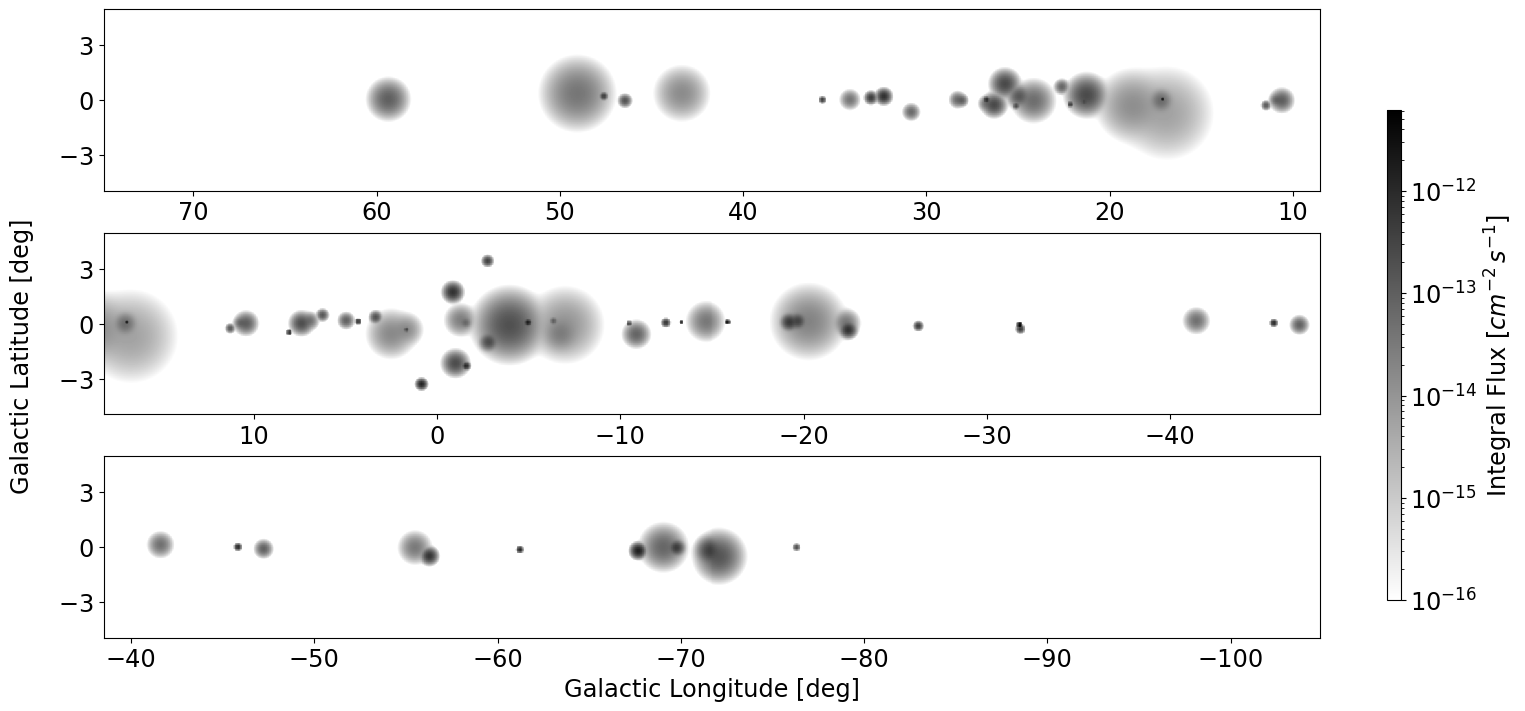

In [45]:
# Use gammapop's built-in visualization
plot_sky_map(sky_map)

## 6. Apply Angular Resolution (PSF Convolution)

**Angular Resolution:** 0.1° FWHM Gaussian PSF  
**Conversion:** FWHM = 2.355 × σ → σ = FWHM / 2.355 ≈ 0.0425°

In [69]:
# Angular resolution parameters
fwhm_deg = 1.0  # degrees
sigma_deg = fwhm_deg / 2.355

# Get pixel size from the sky map geometry
pixel_size = sky_map.geom.pixel_scales.mean().to('deg').value
sigma_pix = sigma_deg / pixel_size

print(f"Sky map shape: {sky_map.data.shape}")
print(f"Sky map ndim: {sky_map.data.ndim}")
print(f"PSF FWHM: {fwhm_deg}°")
print(f"PSF sigma: {sigma_deg:.4f}° = {sigma_pix:.2f} pixels")
print(f"Pixel size: {pixel_size:.4f}°")

# Create Gaussian PSF kernel
psf_kernel = Gaussian2DKernel(x_stddev=sigma_pix, y_stddev=sigma_pix)

# Apply convolution - handle different dimensionalities
if sky_map.data.ndim == 2:
    # 2D map - direct convolution
    flux_data_convolved = convolve(sky_map.data, psf_kernel, boundary='extend')
elif sky_map.data.ndim == 3:
    # 3D map (e.g., with energy axis) - convolve only spatial dimensions
    # Sky map is typically [energy, lat, lon] or similar
    flux_data_convolved = np.zeros_like(sky_map.data)
    for i in range(sky_map.data.shape[0]):
        flux_data_convolved[i] = convolve(sky_map.data[i], psf_kernel, boundary='extend')
else:
    raise ValueError(f"Unexpected sky map dimensions: {sky_map.data.ndim}")

# Create PSF-convolved map
sky_map_psf = Map.from_geom(sky_map.geom, data=flux_data_convolved, unit=sky_map.unit)

print(f"\nOriginal sky map: max={sky_map.data.max():.2e}, min={sky_map.data.min():.2e}")
print(f"After PSF: max={sky_map_psf.data.max():.2e}, min={sky_map_psf.data.min():.2e}")

Sky map shape: (1, 100, 1700)
Sky map ndim: 3
PSF FWHM: 1.0°
PSF sigma: 0.4246° = 4.25 pixels
Pixel size: 0.1000°

Original sky map: max=6.15e-12, min=0.00e+00
After PSF: max=1.37e-13, min=0.00e+00


## 7. Visualize PSF-Convolved Map

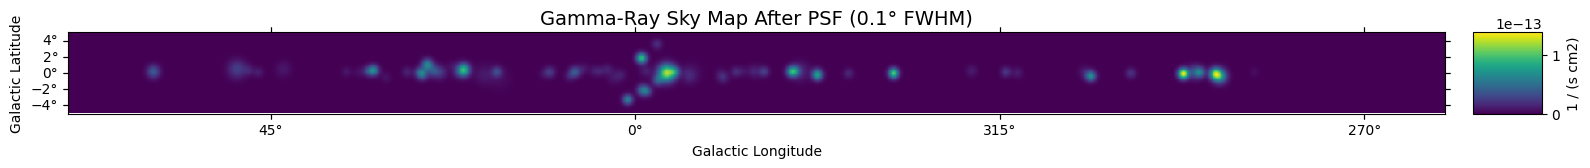

In [70]:
fig, ax = plt.subplots(figsize=(16, 6), subplot_kw={'projection': sky_map_psf.geom.wcs})
sky_map_psf.plot(ax=ax, add_cbar=True, cmap='viridis')
ax.set_title('Gamma-Ray Sky Map After PSF (0.1° FWHM)', fontsize=14)
ax.set_xlabel('Galactic Longitude')
ax.set_ylabel('Galactic Latitude')
plt.tight_layout()
plt.show()

## 8. Comparison: Before vs After PSF

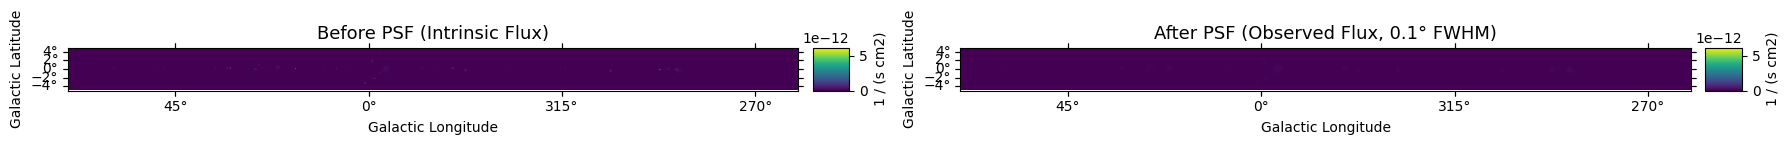

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), subplot_kw={'projection': sky_map.geom.wcs})

# Determine common colorbar limits
vmax = max(sky_map.data.max(), sky_map_psf.data.max())
vmin = 0

sky_map.plot(ax=axes[0], add_cbar=True, cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title('Before PSF (Intrinsic Flux)', fontsize=13)
axes[0].set_xlabel('Galactic Longitude')
axes[0].set_ylabel('Galactic Latitude')

sky_map_psf.plot(ax=axes[1], add_cbar=True, cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title('After PSF (Observed Flux, 0.1° FWHM)', fontsize=13)
axes[1].set_xlabel('Galactic Longitude')
axes[1].set_ylabel('Galactic Latitude')

plt.tight_layout()
plt.show()

## 9. Peak Detection with Gammapy

Using `find_peaks_in_flux_map` to detect local maxima above a threshold. The function requires a `FluxMaps` object.

In [72]:
# Create a significance map as a proxy (flux normalized by std deviation)
# In real analysis, this would be proper TS (test statistic) from likelihood fitting
background_level = np.median(sky_map_psf.data[sky_map_psf.data > 0])
significance_proxy = (sky_map_psf.data - background_level) / np.std(sky_map_psf.data)

# Since our map is 3D (energy, lat, lon), we need to squeeze it to 2D for peak finding
# Take the first energy bin (we only have one anyway)
if sky_map_psf.data.ndim == 3:
    flux_2d = sky_map_psf.data[0]  # First energy bin
    significance_2d = significance_proxy[0]
else:
    flux_2d = sky_map_psf.data
    significance_2d = significance_proxy

# Create 2D geometry (remove energy axis)
from gammapy.maps import WcsGeom
geom_2d = WcsGeom(wcs=sky_map_psf.geom.wcs, npix=sky_map_psf.geom.npix[:2])

# Create 2D maps for peak finding
flux_map_2d = Map.from_geom(geom_2d, data=flux_2d, unit=sky_map_psf.unit)
significance_map_2d = Map.from_geom(geom_2d, data=significance_2d, unit='')

# Peak detection parameters
threshold = 3.0  # detection threshold in sigma-equivalent
min_distance = 0.3 * u.deg  # minimum separation between peaks

print(f"Peak detection threshold: {threshold} sigma")
print(f"Minimum peak separation: {min_distance}")
print(f"Background level: {background_level:.2e}")
print(f"Map shape (2D): {flux_map_2d.data.shape}")
print(f"Significance range: [{significance_map_2d.data.min():.2f}, {significance_map_2d.data.max():.2f}]")

Peak detection threshold: 3.0 sigma
Minimum peak separation: 0.3 deg
Background level: 3.76e-23
Map shape (2D): (100, 1700)
Significance range: [-0.00, 16.16]


## 10. Find Peaks

In [73]:
# Find peaks using the simpler find_peaks function on the significance map
from gammapy.estimators.utils import find_peaks

# Find peaks in the significance map
peaks = find_peaks(
    significance_map_2d,
    threshold=threshold,
    min_distance=min_distance
)

# Add flux values at peak positions
if len(peaks) > 0:
    # Get flux values at peak positions
    flux_at_peaks = []
    for i in range(len(peaks)):
        # Create SkyCoord with explicit units
        coord = SkyCoord(
            ra=peaks['ra'][i] * u.deg, 
            dec=peaks['dec'][i] * u.deg, 
            frame='icrs'
        )
        flux_val = flux_map_2d.interp_by_coord(coord)
        # Handle both array and scalar returns
        if isinstance(flux_val, np.ndarray):
            flux_at_peaks.append(flux_val.item())
        else:
            flux_at_peaks.append(flux_val)
    
    peaks['flux'] = flux_at_peaks * flux_map_2d.unit
    peaks['sqrt_ts'] = peaks['value']  # Rename for consistency
    peaks.remove_column('value')
    
    print(f"\n Detected {len(peaks)} peaks above {threshold} sigma threshold:")
    print(peaks[['ra', 'dec', 'flux', 'sqrt_ts']])
else:
    print(f"\n No peaks detected above {threshold} sigma threshold")
    print(f"   Try lowering the threshold or checking your flux map.")


 Detected 20 peaks above 3.0 sigma threshold:
    ra       dec             flux          sqrt_ts
   deg       deg         1 / (s cm2)              
--------- --------- ---------------------- -------
162.93579 -59.68935  1.373429036455991e-13  16.162
170.40492 -61.26273 1.3560064657047462e-13  15.957
264.12128 -32.36658 1.2094357217949794e-13  14.232
238.94663 -53.74148  9.900389828901746e-14  11.651
252.19183 -44.79391  9.666457108926302e-14  11.375
277.24845 -10.26563  9.533739684762751e-14  11.219
264.35386 -28.70089  8.855069509964027e-14   10.42
249.79654 -47.32360  7.706108550272602e-14  9.0683
282.46062  -0.44950  6.927222900371302e-14  8.1518
194.90353 -63.30717  6.650691391278806e-14  7.8264
166.92525 -60.38321  6.529553580455809e-14  7.6838
278.76533  -6.08655  6.480638354262318e-14  7.6262
279.98176  -5.92389  6.416810790888788e-14  7.5511
267.94794 -31.08083  6.048293283332478e-14  7.1175
270.27116 -29.81649  5.520031271640951e-14  6.4958
270.64587 -22.53788   4.08270772996

## 11. Visualize Detected Peaks on Sky Map

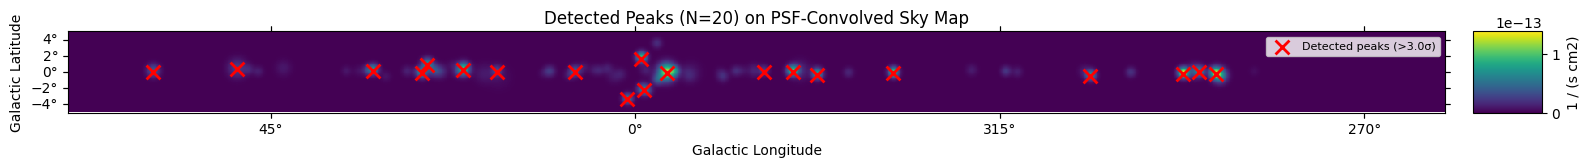

In [74]:
fig, ax = plt.subplots(figsize=(16, 6), subplot_kw={'projection': sky_map_psf.geom.wcs})

# Plot PSF-convolved flux map
sky_map_psf.plot(ax=ax, add_cbar=True, cmap='viridis')
ax.set_title(f'Detected Peaks (N={len(peaks)}) on PSF-Convolved Sky Map', fontsize=12)
ax.set_xlabel('Galactic Longitude')
ax.set_ylabel('Galactic Latitude')

# Overlay detected peaks as red crosses
if len(peaks) > 0:
    peak_coords = SkyCoord(peaks['ra'], peaks['dec'], unit='deg', frame='icrs')
    peak_gal = peak_coords.galactic
    ax.scatter(
        peak_gal.l.deg, peak_gal.b.deg,
        transform=ax.get_transform('galactic'),
        s=100, marker='x', color='red', linewidths=2,
        label=f'Detected peaks (>{threshold}σ)'
    )
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

## 12. Summary Table of Detected Sources

In [77]:
if len(peaks) > 0:
    # Convert to Galactic coordinates for easier comparison
    peak_coords = SkyCoord(peaks['ra'], peaks['dec'], unit='deg', frame='icrs')
    peak_gal = peak_coords.galactic
    
    summary = Table()
    summary['Source'] = [f"Peak_{i+1}" for i in range(len(peaks))]
    summary['GLON'] = peak_gal.l.deg
    summary['GLAT'] = peak_gal.b.deg
    summary['Flux'] = peaks['flux']
    summary['Significance'] = peaks['sqrt_ts']
    
    print("\n=== DETECTED SOURCES ===")
    summary.pprint(max_lines=-1, max_width=-1)
else:
    print("No peaks detected above threshold.")


=== DETECTED SOURCES ===
 Source        GLON                 GLAT                  Flux          Significance
                                                      1 / (s cm2)                   
------- ------------------ --------------------- ---------------------- ------------
 Peak_1             288.35    -0.250000000000063  1.373429036455991e-13       16.162
 Peak_2             292.35  -0.25000000000005274 1.3560064657047462e-13       15.957
 Peak_3             356.05  -0.14999999999995936 1.2094357217949794e-13       14.232
 Peak_4  328.1499999999999   -0.1500000000000143  9.900389828901746e-14       11.651
 Peak_5             340.55     0.049999999999988  9.666457108926302e-14       11.375
 Peak_6  21.24999999999999    0.2500000000000156  9.533739684762751e-14       11.219
 Peak_7 359.24999999999994    1.6499999999999955  8.855069509964027e-14        10.42
 Peak_8 337.54999999999995   -0.3499999999999825  7.706108550272602e-14       9.0683
 Peak_9              32.35   0.15000000

## 13. Export Maps and Catalog to FITS

In [ ]:

#sky_map.write('sky_map_original.fits', overwrite=True)
#sky_map_psf.write('sky_map_psf_convolved.fits', overwrite=True)
#if len(peaks) > 0:
#    peaks.write('detected_peaks_catalog.fits', overwrite=True)
#print("Maps and peak catalog saved to FITS files.")

Maps and peak catalog saved to FITS files.
